# Evaluate fitting on experimental data

To evaluate PyCheMelt's performance on an experimental dataset the ACBP dataset from Hamborg et al. (2020) was processed and used. This datasets provides 16 thermal denaturation curves with differing concentrations of GuHCl. This dataset was thus used to fit the parameters in a 2 dimensional fashion to the curves regarding temperature and chemical denaturation.

In [5]:
import numpy as np
import pandas as pd

from plotly.subplots import make_subplots

from pychemelt import Monomer
from pychemelt.utils.plotting import *
from pychemelt.utils.processing import (
    get_colors_from_numeric_values,
    combine_sequences
)

import plotly.graph_objs as go


In [6]:
from pathlib import Path

data_file = Path("../../test_files/20191202_ACBP_15C_95C_processed.xlsx")
if not data_file.exists():
    data_file = Path("test_files/20191202_ACBP_15C_95C_processed.xlsx")

data_file

PosixPath('../../test_files/20191202_ACBP_15C_95C_processed.xlsx')

In [7]:
def display_figure_static(fig, format="png", width=800, height=600, show_interactive=False):
    """
    Display a Plotly figure in both interactive and static formats.

    This function is useful for Jupyter notebooks that need to render properly
    on GitHub, where interactive Plotly figures may not display.

    Parameters
    ----------
    fig : go.Figure
        Plotly figure object to display
    format : str, default "png"
        Image format for static display ("png", "svg", "jpeg")
    show_interactive : bool, default True
        Whether to also show the interactive version

    """
    try:
        # Try to import display functionality
        from IPython.display import Image, display

        # Show interactive version first (for local Jupyter)
        if show_interactive:
            fig.show()

        # Display static version (for GitHub compatibility)
        static_image = fig.to_image(format=format, width=width, height=height, scale=2)
        display(Image(static_image))

    except ImportError:
        # Fallback to regular show if not in Jupyter
        print("IPython not available, showing interactive figure only")
        fig.show()
    except Exception as e:
        print(f"Error creating static image: {e}")
        print("Showing interactive figure only")
        fig.show()

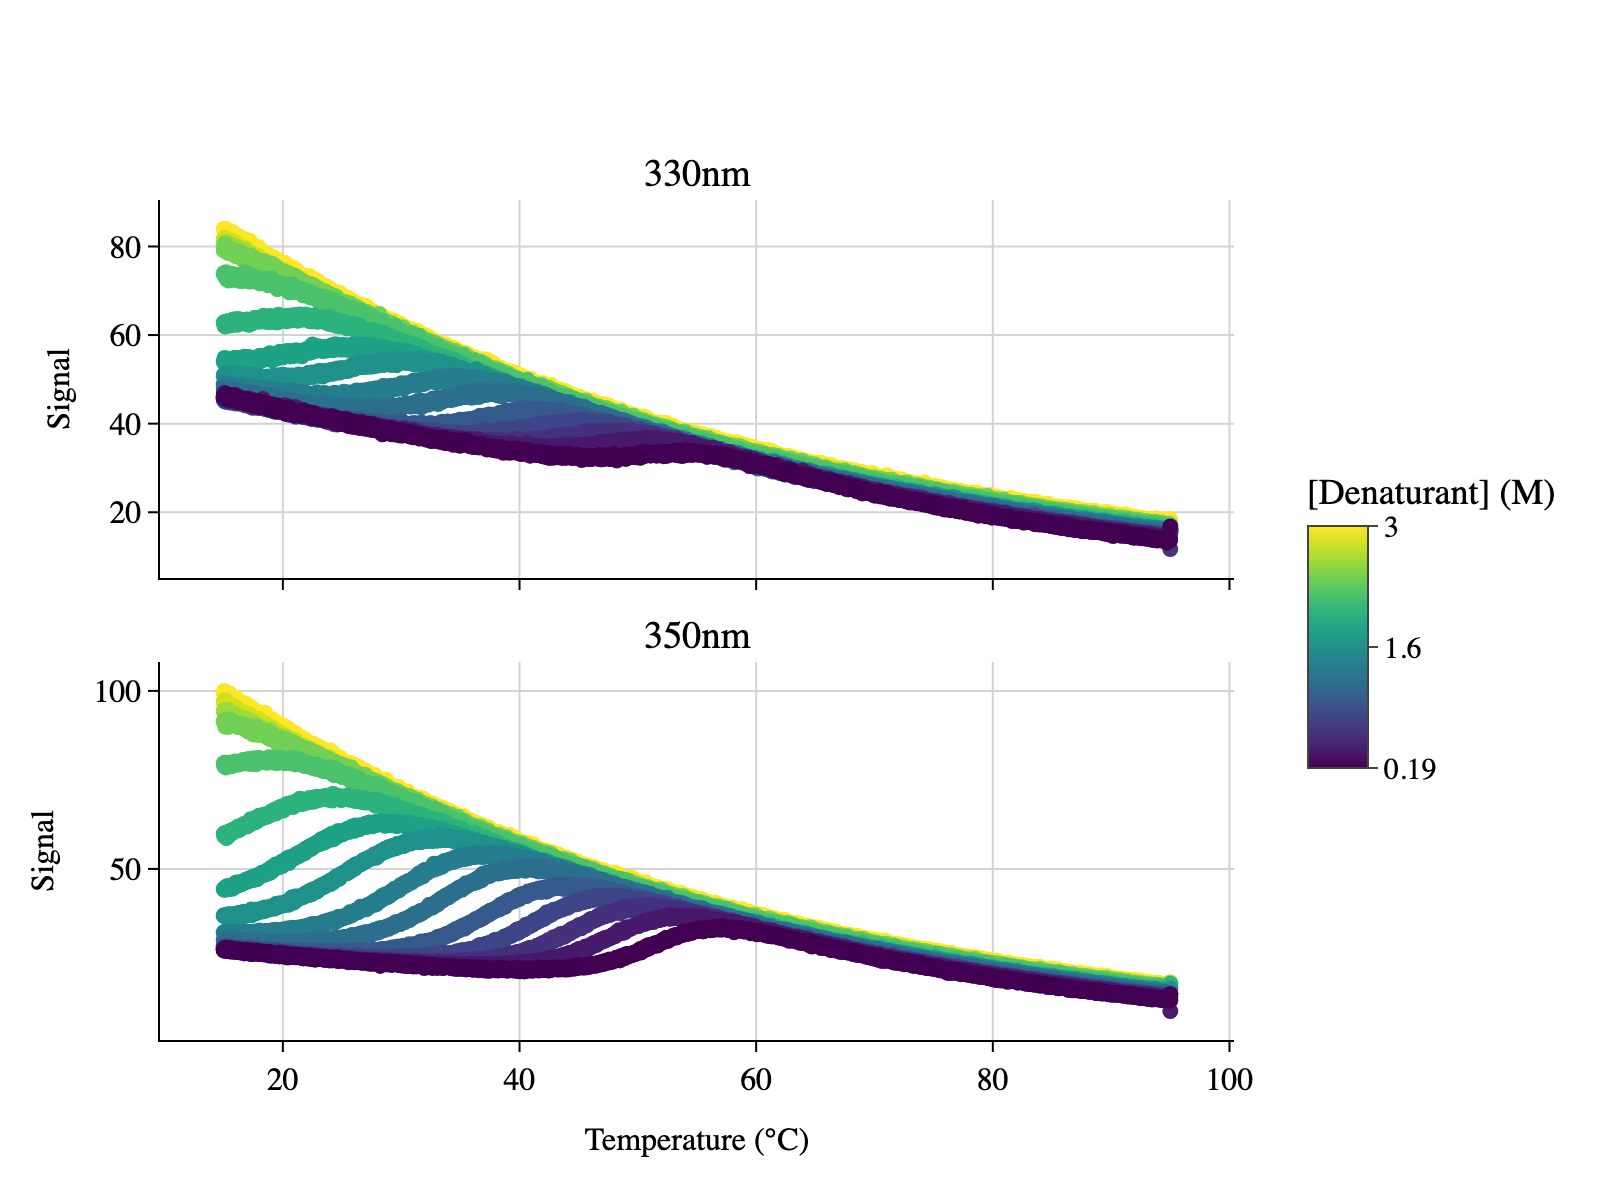

In [4]:
# creating a Sample object for the storage and processing of the DSF data
sample = Monomer()

# reading the data
sample.read_file(data_file)

sample.set_denaturant_concentrations()

# Selecting conditions
sample.set_signal(['330nm', '350nm'])

#using all curves except the curve without denaturant as in the paper
sample.select_conditions([True]*15 + [False])


#Plotting the selected signals against the temperature
fig = plot_unfolding(sample)
display_figure_static(fig)

In [8]:
# Reducing the amount of data and preprocessing steps for a faster analysis
sample.pre_fit = False
sample.max_points = 200


sample.expand_multiple_signal()

# For the estimates of the baselines, linear was used for the folded protein and exponential for the unfolded.
# the exponential baseline for the unfolded was preferred over quadratic as it previously was shown to generalize 
# better and ran faster in during testing.
sample.estimate_baseline_parameters(
    native_baseline_type='linear',
    unfolded_baseline_type='exponential',
)

# estimations of parameters
sample.estimate_derivative()
sample.guess_Tm()

# All local fit for parameter estimation
sample.fit_thermal_unfolding_local()

# Setting the number of residues of the protein for an initial estiamte of the Cp value
sample.n_residues = 86 # doi: 10.1042/bj2450857
sample.guess_Cp()


sample.set_signal_id()

In [9]:
fitting_results = {
    "Tm (°C)":[],
    "ΔH (kcal/mol)":[],
    "Cp (kcal/mol/°C)":[],
    "m-value (kcal/mol/M)":[],
    "ΔG-H2O (kcal/mol)":[],
}

# Fit with global thermodynamic parameters, global slopes and global baselines
sample.fit_thermal_unfolding_global()
sample.fit_thermal_unfolding_global_global()
sample.fit_thermal_unfolding_global_global_global()

# Save the fitted thermodynamic parameters

Tm = sample.params_df.iloc[0,1]
dH = sample.params_df.iloc[1,1]
Cp = sample.params_df.iloc[2,1]
m = sample.params_df.iloc[3,1]
dG = sample.dg_df.iloc[50,0]

fitting_results["Tm (°C)"].append(Tm)
fitting_results["ΔH (kcal/mol)"].append(dH)
fitting_results["Cp (kcal/mol/°C)"].append(Cp)
fitting_results["m-value (kcal/mol/M)"].append(m)
fitting_results["ΔG-H2O (kcal/mol)"].append(dG)


plot_unfolding(sample)

In [10]:
# Estimate the asymmetric confidence intervals for the fitted parameters using the profile likelihood method
sample.calculate_confidence_intervals(percentage=0.95)
print(sample.ci_df)

                  Parameter  Lower_CI_95.0%  Value  Upper_CI_95.0%
0                   Tm (°C)           53.56  53.63           53.71
1          ΔHm (kcal / mol)           75.29  75.87           76.46
2        ΔCp (kcal / mol K)            1.01   1.03            1.05
3  m-value (kcal / mol / M)            3.17   3.19            3.22


In [11]:
# Estimate parameter errors using leave-one-out cross-validation
sample.leave_one_out_cross_validation()
print(sample.loo_df)

                  Parameter  Leave_one_out_mean  Leave_one_out_std  N fits
0                   Tm (°C)           53.629784           0.071063      15
1          ΔHm (kcal / mol)           75.970935           0.629319      15
2      ΔCp (kcal / mol / K)            1.030101           0.015496      15
3  m-value (kcal / mol / M)            3.197493           0.016590      15


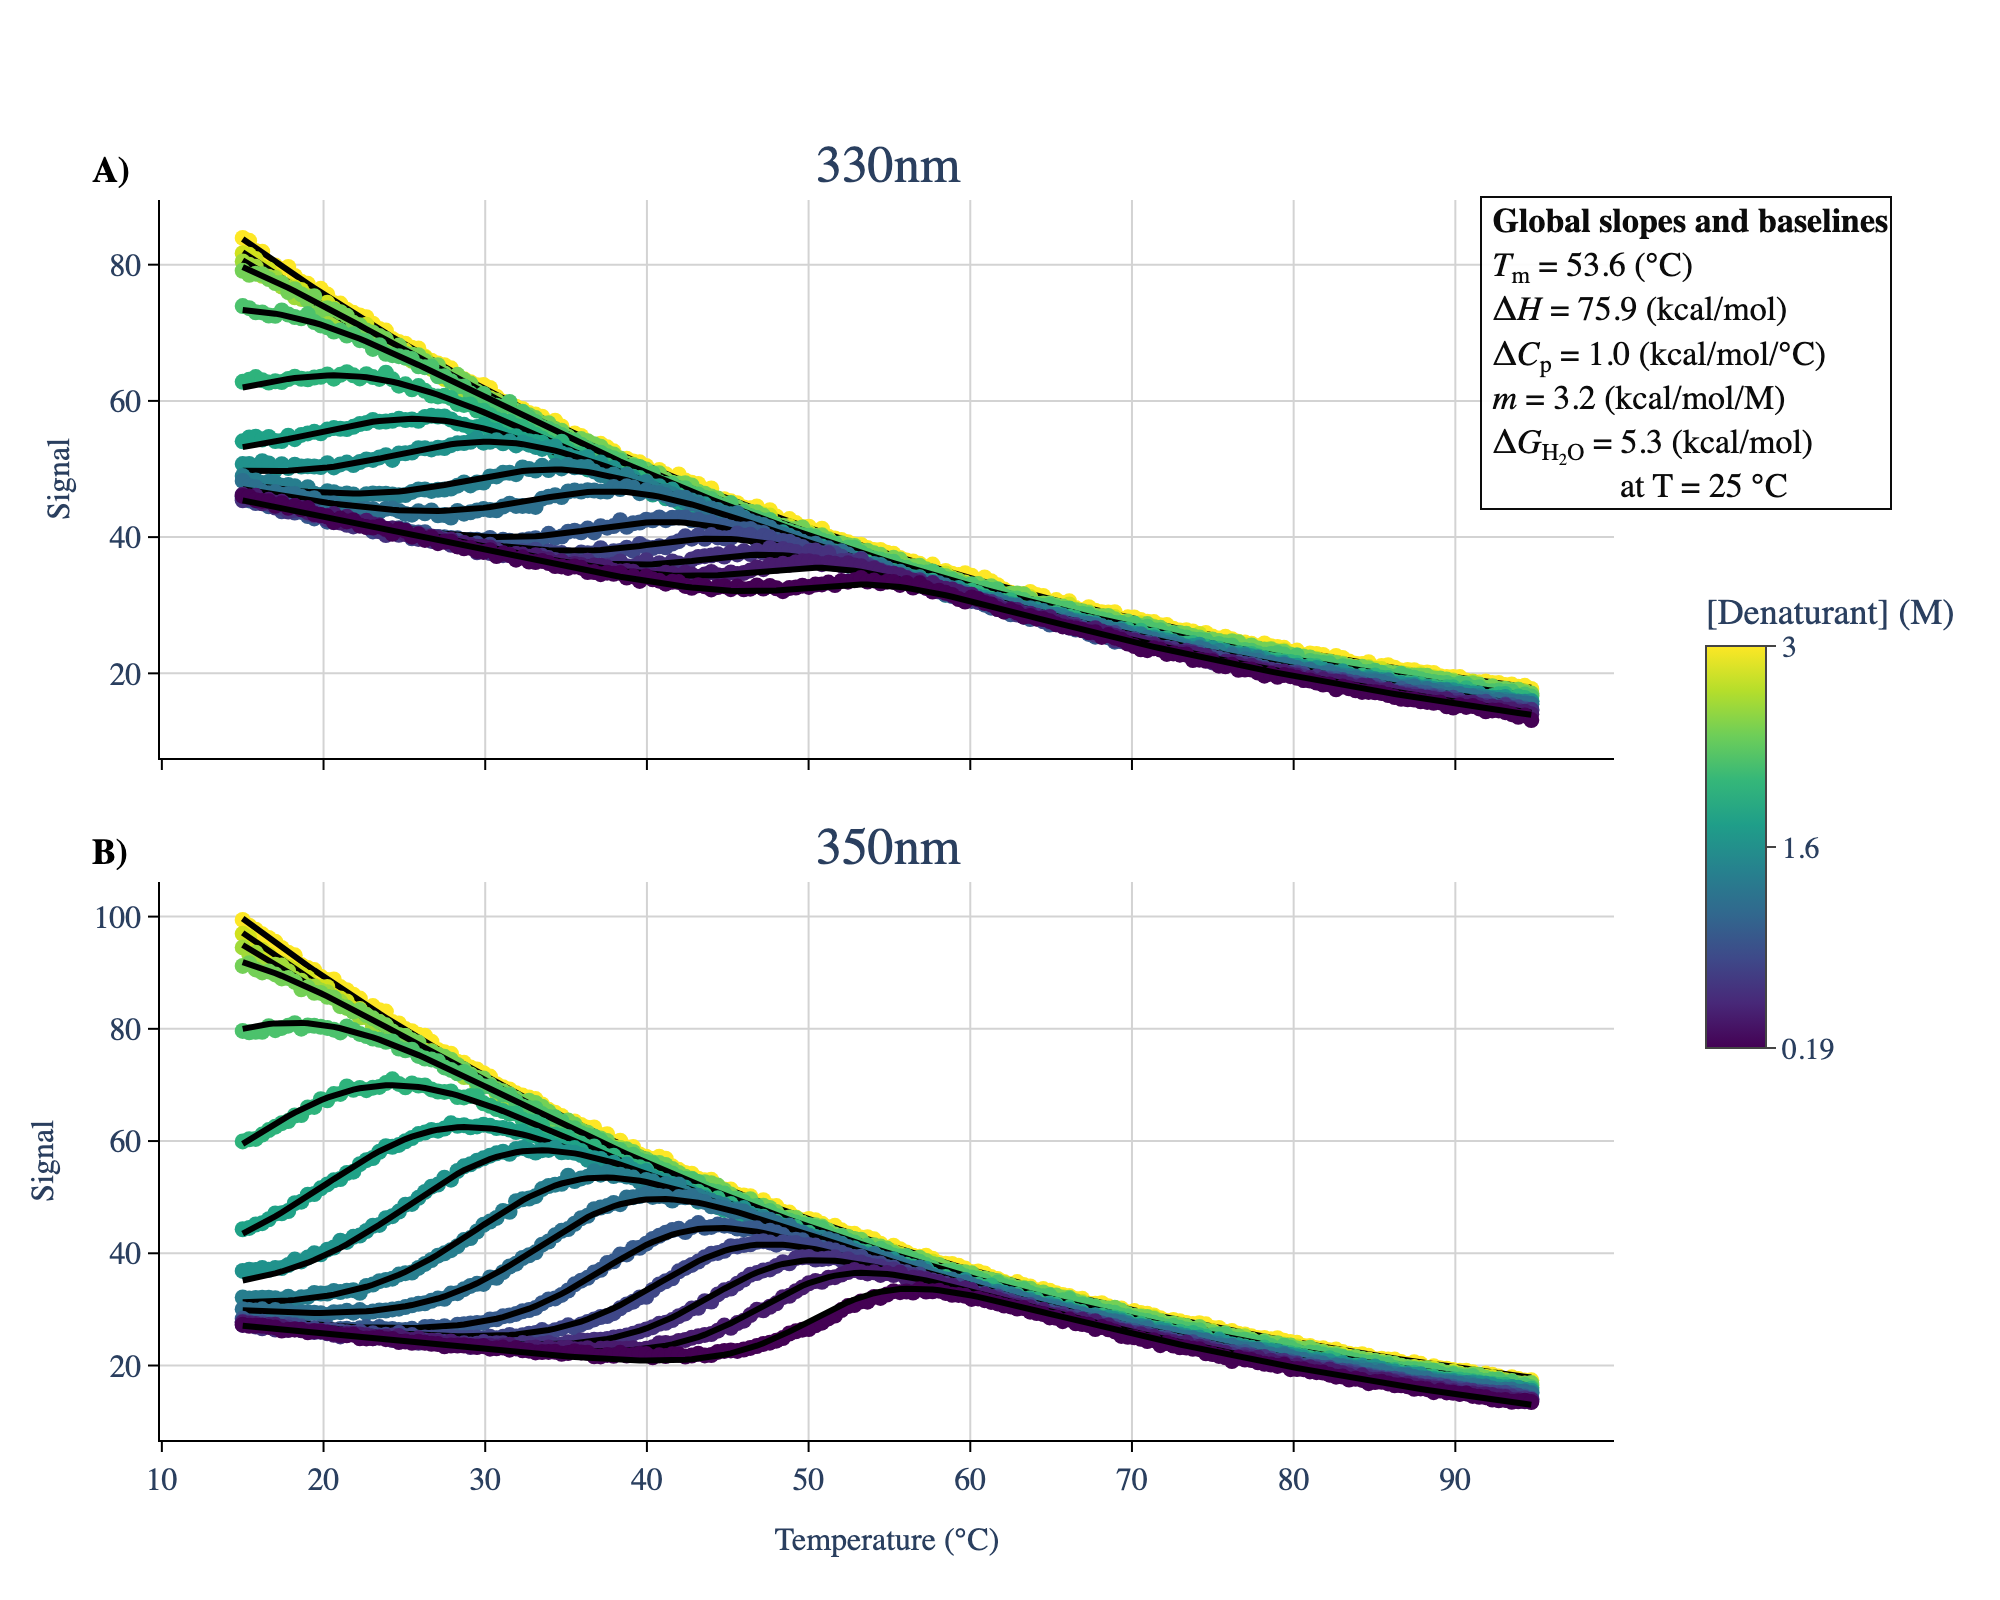

In [12]:
# modifying the plot_unfolding method for the generation of the figure

# Set defaults for configuration objects
plot_config = PlotConfig()
axis_config = AxisConfig()
layout_config = LayoutConfig()
legend_config = LegendConfig()

# Extract the minimum and maximum denaturation concentration
concs = sample.denaturant_concentrations

min_conc = np.min(concs)
max_conc = np.max(concs)

colors = get_colors_from_numeric_values(concs, min_conc, max_conc)

n_subplots = sample.nr_signals

# Set number of rows: 2 if less than 8 plots, else 3
nrows = 2 if n_subplots < 9 else 3
nrows = min(nrows, n_subplots)  # Do not exceed the number of plots - case n equal 1

ncols = int(np.ceil(n_subplots / nrows))

row_arr = np.arange(1, nrows + 1)
col_arr = np.arange(1, ncols + 1)
# Row and column counters for subplotting
row_col_info = combine_sequences(row_arr, col_arr)

subplot_titles = sample.signal_names

fig = make_subplots(
    rows=nrows,
    cols=ncols,
    shared_xaxes=True,
    shared_yaxes=False,
    vertical_spacing=layout_config.vertical_spacing,
    subplot_titles=subplot_titles)

subplot_idx = 0

fittings_done = sample.global_fit_params is not None

ys_fit = None

nr_den = sample.nr_den

for i in range(n_subplots):

    row = row_col_info[subplot_idx][0]
    col = row_col_info[subplot_idx][1]

    ys_fit = sample.predicted_lst_multiple[i]
    xs     = sample.temp_lst_expanded[i*nr_den:(i+1)*nr_den]
    ys     = sample.signal_lst_expanded[i*nr_den:(i+1)*nr_den]


    for j,conc in enumerate(concs):

        color = colors[j]

        x = xs[j]
        y = ys[j]

        fig.add_trace(
            go.Scatter(
                x=x, y=y, mode='markers',
                marker=dict(size=plot_config.marker_size, color=color),
                name=f'{conc:.2f} M',
                showlegend=False
            ),
            row=row, col=col
        )



        # count np.nans in ys_fit
        ys_fit_j = ys_fit[j]

        fig.add_trace(
            go.Scatter(
                x=x, y=ys_fit_j, mode='lines',
                line=dict(color='black', width=plot_config.line_width),
                showlegend=False,
                hoverinfo='skip',
                hovertemplate=None
            ),
            row=row, col=col
        )

    subplot_idx += 1

    # Add an annotation inside the subplot showing the subfigure numeration
    axis_index = i + 1
    # Plotly expects 'x domain'/'y domain' (no '1') for the first axis; for others use 'xN domain'
    if axis_index == 1:
        xref = 'x domain'
        yref = 'y domain'
    else:
        xref = f'x{axis_index} domain'
        yref = f'y{axis_index} domain'

    # Add panel label (A, B, C, etc.)
    panel_label = chr(65 + i)  # 65 is ASCII code for 'A'
    fig.add_annotation(
        x=-0.05,
        y=1.1,
        xref=xref,
        yref=yref,
        text=f'<b>{panel_label})</b>',
        showarrow=False,
        align='left',
        font=dict(size=18, color='black')
    )

# Update subplot layout with white background and axis styling
fig.update_layout(
    font_family="Roboto",
    plot_bgcolor='white',
    paper_bgcolor='white',
    legend=dict(font=dict(size=plot_config.font_size - 1))
)

for i in range(n_subplots):

    row = row_col_info[i][0]
    col = row_col_info[i][1]

    # Set the x-axis title only for the last row
    title_text_x = 'Temperature (°C)' if row == nrows else ''

    # Set the y-axis title only for the first column
    title_text_y = 'Signal' if col == 1 else ''

    fig.update_xaxes(
        title_text=title_text_x,
        showgrid=axis_config.showgrid_x,
        gridwidth=axis_config.gridwidth,
        gridcolor='lightgray',
        showline=True,
        linewidth=axis_config.linewidth,
        linecolor='black',
        zeroline=False,
        tickcolor='black',
        ticks="outside",
        tickwidth=axis_config.tickwidth,
        ticklen=axis_config.ticklen,
        title_font_size=plot_config.font_size,
        tickfont_size=plot_config.font_size,
        col = col,
        row = row
    )

    fig.update_yaxes(
        title_text=title_text_y,
        showgrid=axis_config.showgrid_y,
        gridwidth=axis_config.gridwidth,
        gridcolor='lightgray',
        showline=True,
        linewidth=axis_config.linewidth,
        linecolor='black',
        zeroline=False,
        tickcolor='black',
        ticks="outside",
        tickwidth=axis_config.tickwidth,
        ticklen=axis_config.ticklen,
        title_font_size=plot_config.font_size,
        tickfont_size=plot_config.font_size,
        nticks = axis_config.n_y_axis_ticks,
        col=col,
        row=row
    )

# Build colorbar dict using legend_config values (orientation and x/y position)
# Choose sensible anchors depending on orientation
_xanchor = 'center' if legend_config.color_bar_orientation == 'h' else 'left'
_yanchor = 'top'    if legend_config.color_bar_orientation == 'h' else 'middle'

colorbar_dict = dict(
    title='[Denaturant] (M)',
    tickvals=[min_conc, 0.5*(min_conc + max_conc), max_conc],
    ticktext=[f"{min_conc:.2g}", f"{(min_conc + max_conc) * 0.5:.2g}", f"{max_conc:.2g}"],
    len=legend_config.color_bar_length,
    outlinewidth=1,
    ticks='outside',
    tickfont=dict(size=plot_config.font_size - 1),
    orientation=legend_config.color_bar_orientation,
    x=legend_config.color_bar_x_pos,
    y=legend_config.color_bar_y_pos,
    xanchor=_xanchor,
    yanchor=_yanchor
)


fig.add_trace(
    go.Scatter(
        x=[None], y=[None], mode='markers',
        marker=dict(
            colorscale='Viridis',
            cmin=min_conc,
            cmax=max_conc,
            colorbar=colorbar_dict
        ),
        showlegend=False,
        hoverinfo='skip'
    ),
    row=1, col=1
)


# Adding the thermodynamic parameters of the fitted formula 
fig.add_annotation(
    x=legend_config.color_bar_x_pos ,
    y=legend_config.color_bar_y_pos + 0.25,  # move ABOVE colorbar
    xref="paper",
    yref="paper",
    xanchor="center",
    yanchor="bottom",
    showarrow=False,
    align="left",
    text=(
        " <b>Global slopes and baselines</b><br>"
        f" <i>T</i><sub>m</sub> = {Tm:.1f} (°C) <br>"
        f" Δ<i>H</i> = {dH:.1f} (kcal/mol) <br>"
        f" Δ<i>C</i><sub>p</sub> = {Cp:.1f} (kcal/mol/°C) <br>"
        f" <i>m</i> = {m:.1f} (kcal/mol/M) <br>"
        f" Δ<i>G</i><sub>H<sub>2</sub>O</sub> = {dG:.1f} (kcal/mol) <br> "
        f"               at T = 25 °C"
    ),
    font=dict(
        size=plot_config.font_size + 1,
        color="black"
    ),
    bgcolor="white",
    bordercolor="black",
    borderwidth=1,
    opacity=0.95
)


#changing the subplot title sizes

def is_subplot_title(x):
    return x.text in ["330nm", "350nm"]

fig.update_annotations(
    selector=is_subplot_title,
    patch=dict(font=dict(size=plot_config.font_size + 10))
)

fig = config_fig(
    fig,
    plot_config.width,
    plot_config.height,
    plot_config.type
)

display_figure_static(fig,height=800, width=1000)